In [41]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import*
import tensorflow
import keras
from keras.models import Sequential
from keras.layers import Layer,Dense,Dropout
from keras.optimizers import SGD,Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.callbacks import EarlyStopping





In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.columns

Index(['6', '148', '72', '35', '0', '33.6', '0.627', '50', '1'], dtype='str')

In [4]:
df.shape

(767, 9)

In [5]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFucntion','Age','Outcome']

In [6]:
df = pd.read_csv('diabetes.csv',header=None,names=cols)

In [7]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFucntion,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
col1 = ['Pregnancies','Glucose','BloodPressure']

In [11]:
x1 = df[col1]
x1

,Pregnancies,Glucose,BloodPressure
0,6,148,72
1,1,85,66
2,8,183,64
3,1,89,66
4,0,137,40
...,...,...,...
763,10,101,76
764,2,122,70
765,5,121,72
766,1,126,60


In [12]:
y1 = df['Outcome']

In [13]:
y1

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.2,random_state=42)

In [15]:
x_train.shape , x_test.shape,y_train.shape,y_test.shape

((614, 3), (154, 3), (614,), (154,))

In [16]:
sc = StandardScaler()
x1_train_scaled = sc.fit_transform(x_train)
x1_test_scaled = sc.transform(x_test)

In [17]:
model1 = Sequential(
[    Dense(8,activation='relu',input_shape=(x1_train_scaled.shape[1],)),
    Dense(1,activation='sigmoid')]
    
)

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model1.compile(optimizer=SGD(),loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
history1 = model1.fit(x1_train_scaled,y_train, epochs=100,batch_size=10,validation_data=(x1_test_scaled,y_test))

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6498 - loss: 0.5905 - val_accuracy: 0.6623 - val_loss: 0.5874
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.6580 - loss: 0.5810 - val_accuracy: 0.6494 - val_loss: 0.5779
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - accuracy: 0.6645 - loss: 0.5734 - val_accuracy: 0.6623 - val_loss: 0.5699
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - accuracy: 0.6840 - loss: 0.5671 - val_accuracy: 0.6948 - val_loss: 0.5631
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.7003 - loss: 0.5619 - val_accuracy: 0.7338 - val_loss: 0.5575
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step - accuracy: 0.7068 - loss: 0.5576 - val_accuracy: 0.7403 - val_loss: 0.5533
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - accuracy: 0.7231 - loss: 0.5544 - val_accuracy: 0.7468 - val_loss: 0.5495
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - accuracy: 0.7329 - loss: 0.5515 - val_accura

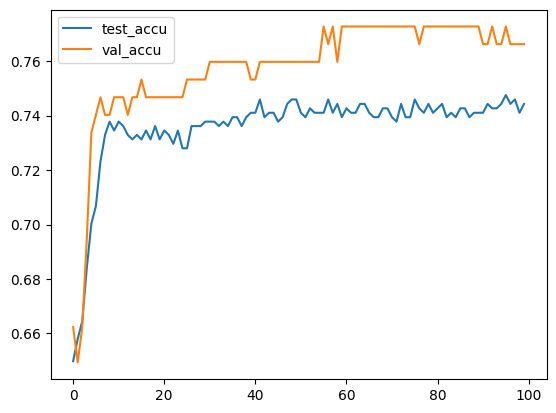

In [20]:
plt.plot(history1.history['accuracy'],label='test_accu')
plt.plot(history1.history['val_accuracy'],label='val_accu')
plt.legend()
plt.show()

In [21]:
x2 = df.iloc[:,:-1]
y2 = df.iloc[:,-1]

In [22]:
y2

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [23]:
x2_train,x2_test,y2_train,y2_test = train_test_split(x2,y2,test_size=0.20,random_state=42)

In [24]:
sc2 = StandardScaler()
x2_train_scaled= sc2.fit_transform(x2_train)
x2_test_scaled = sc2.transform(x2_test)

In [25]:
model2 = Sequential(
    [
        Dense(16,activation='relu',input_shape= (x2_train_scaled.shape[1],)),
        Dense(16,activation='relu'),
        Dense(16,activation='relu'),
        Dense(1,activation='sigmoid')
    ]
)

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model2.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

In [28]:
history2 =model2.fit(x2_train_scaled,y2_train,epochs=150,batch_size=10,validation_data=(x2_test_scaled,y2_test))

Epoch 1/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9153 - loss: 0.2119 - val_accuracy: 0.7078 - val_loss: 1.0253
Epoch 2/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - accuracy: 0.9121 - loss: 0.2119 - val_accuracy: 0.7208 - val_loss: 1.0287
Epoch 3/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.9072 - loss: 0.2132 - val_accuracy: 0.6948 - val_loss: 1.0354
Epoch 4/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - accuracy: 0.9137 - loss: 0.2084 - val_accuracy: 0.7078 - val_loss: 1.0490
Epoch 5/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9072 - loss: 0.2135 - val_accuracy: 0.7078 - val_loss: 1.0403
Epoch 6/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.9186 - loss: 0.2059 - val_accuracy: 0.7143 - val_loss: 1.0465
Epoch 7/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.9153 - loss: 0.2045 - val_accuracy: 0.7143 - val_loss: 1.0558
Epoch 8/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.9186 - loss: 0.2027 - val_accuracy

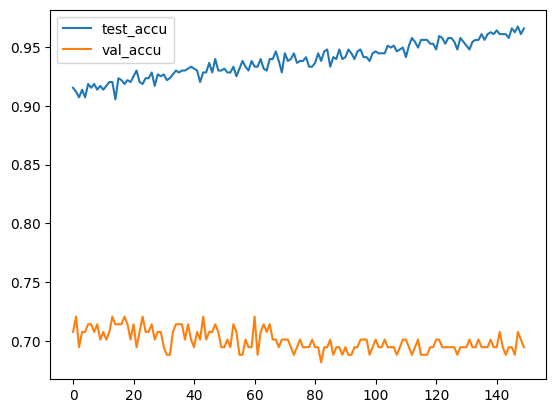

In [31]:
plt.plot(history2.history['accuracy'] ,label="test_accu")
plt.plot(history2.history['val_accuracy'] ,label="val_accu")
plt.legend()
plt.show()

In [34]:
best_model = Sequential(
    [
        Dense(32,activation='relu',input_shape=(x2_train_scaled.shape[1],)),
        Dropout(0.3),
        Dense(16,activation='relu'),
        Dropout(0.2),
        Dense(8,activation='relu'),
        Dense(1,activation='sigmoid')
    ]
)

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
best_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [38]:
history_best = best_model.fit(x2_train_scaled,y2_train,epochs=200,batch_size=10,validation_data=(x2_test_scaled,y2_test))

Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6710 - loss: 0.6552 - val_accuracy: 0.7338 - val_loss: 0.6308
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.7182 - loss: 0.5858 - val_accuracy: 0.7532 - val_loss: 0.5819
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.6971 - loss: 0.5650 - val_accuracy: 0.7532 - val_loss: 0.5450
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.7443 - loss: 0.5281 - val_accuracy: 0.7662 - val_loss: 0.5218
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.7476 - loss: 0.5132 - val_accuracy: 0.7792 - val_loss: 0.5138
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.7557 - loss: 0.4908 - val_accuracy: 0.7792 - val_loss: 0.5082
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.7687 - loss: 0.4882 - val_accuracy: 0.7662 - val_loss: 0.5047
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.7671 - loss: 0.4790 - val_accura

In [39]:
loss ,acc = best_model.evaluate(x2_test_scaled,y2_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7273 - loss: 0.6368


In [40]:
print("accuracy:" ,acc)

accuracy: 0.7272727489471436


In [42]:
callbacks = [
    EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)
]

In [43]:
history_best = best_model.fit(x2_train_scaled,y2_train,epochs=200,batch_size=10,validation_data=(x2_test_scaled,y2_test),callbacks=callbacks)

Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8453 - loss: 0.3741 - val_accuracy: 0.7208 - val_loss: 0.6396
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.8339 - loss: 0.3765 - val_accuracy: 0.7208 - val_loss: 0.6409
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - accuracy: 0.8241 - loss: 0.3812 - val_accuracy: 0.7208 - val_loss: 0.6357
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.8355 - loss: 0.3691 - val_accuracy: 0.7273 - val_loss: 0.6430
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.8339 - loss: 0.3727 - val_accuracy: 0.7208 - val_loss: 0.6444
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.8322 - loss: 0.3701 - val_accuracy: 0.7273 - val_loss: 0.6567
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.8436 - loss: 0.3565 - val_accuracy: 0.7143 - val_loss: 0.6637
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - accuracy: 0.8257 - loss: 0.4025 - val_accura

In [45]:
loss ,acc = best_model.evaluate(x2_test_scaled,y2_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7208 - loss: 0.6357


In [46]:
print("accuarcy: ",acc)

accuarcy:  0.7207792401313782
